In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
from fastai.tabular.all import *

pd.options.display.float_format = '{:.2f}'.format
set_seed(42)

In [4]:
df = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [7]:
df.isna().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

### Woah super cleaned data!

## 1. Preprocessing

In [9]:
train = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [10]:
test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [11]:
test.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [12]:
test.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [14]:
len(test.columns) + 1 == len(train.columns)

True

In [24]:
categorical = ['road_type','lighting','weather','road_signs_present',
               'public_road','time_of_day','holiday','school_season']

continuous = ['num_lanes','curvature','speed_limit','num_reported_accidents']
target = 'accident_risk'

In [25]:
procs = [Categorify, FillMissing, Normalize]

# Splitter: use 80-20 split
splits = RandomSplitter(seed=42)(train)

to = TabularPandas(train, procs=procs, cat_names=categorical, cont_names=continuous,
                   y_names=target, splits=splits)


In [30]:
dls = to.dataloaders(bs=1024)

In [31]:
learn = tabular_learner(dls, layers=[200,100], metrics=rmse)
learn.fit_one_cycle(10, 1e-2)  # 10 epochs, learning rate 0.01

epoch,train_loss,valid_loss,_rmse,time
0,0.004931,0.004457,0.066763,00:05
1,0.004142,0.003875,0.062248,00:04
2,0.003631,0.003465,0.058868,00:04
3,0.003432,0.003432,0.058586,00:04
4,0.003351,0.003364,0.058001,00:04
5,0.003306,0.003300,0.057448,00:04
6,0.003253,0.003374,0.058085,00:04
7,0.003272,0.003252,0.057025,00:04
8,0.003253,0.003238,0.056904,00:04
9,0.003213,0.003235,0.056877,00:04


SuggestedLRs(slide=0.0063095735386013985, valley=0.0030199517495930195)

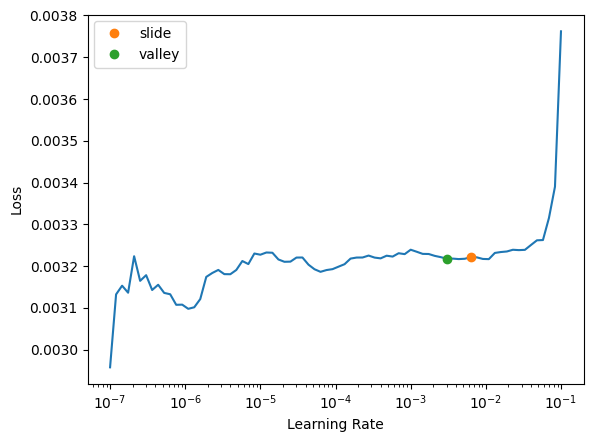

In [32]:
learn.lr_find(suggest_funcs=(slide, valley))

SuggestedLRs(valley=0.00363078061491251)

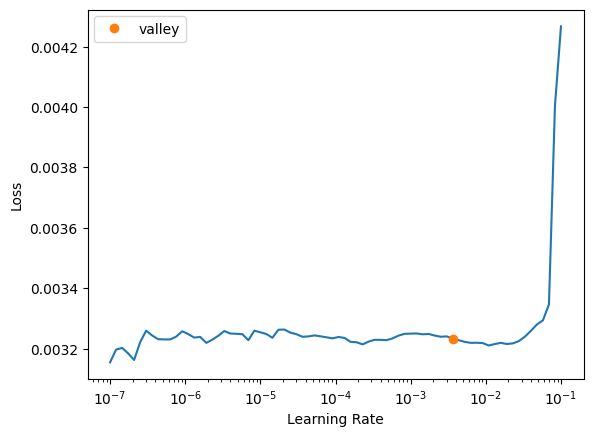

In [37]:
learn.lr_find()

In [38]:
# Remember this optimal lr = 0.0036

In [34]:
learn.show_results()

,road_type,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,accident_risk_pred
0,2.00,2.00,1.00,1.00,1.00,1.00,1.00,2.00,-0.44,-0.33,1.51,0.91,0.26,0.31
1,1.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00,-0.44,-0.95,1.51,0.91,0.36,0.37
2,2.00,1.00,2.00,1.00,1.00,2.00,1.00,1.00,-1.33,-0.25,1.51,-0.21,0.43,0.41
3,3.00,1.00,2.00,1.00,1.00,2.00,2.00,1.00,1.35,0.48,1.51,-0.21,0.55,0.48
4,2.00,2.00,2.00,1.00,2.00,1.00,2.00,1.00,-1.33,-0.84,1.51,0.91,0.41,0.36
5,1.00,1.00,2.00,1.00,1.00,1.00,1.00,2.00,-1.33,-0.51,0.88,-0.21,0.42,0.38
6,1.00,3.00,3.00,2.00,1.00,2.00,2.00,2.00,-1.33,1.77,-0.70,2.02,0.61,0.68
7,3.00,2.00,2.00,2.00,1.00,1.00,1.00,1.00,0.45,1.00,0.88,-0.21,0.56,0.53
8,3.00,3.00,1.00,2.00,1.00,1.00,1.00,1.00,-1.33,-0.40,0.88,0.91,0.50,0.50


## Let's try ensembling the model

In [40]:
    tst_dls = learn.dls.test_dl(test)

In [42]:
preds_list = []

for i in range(5):
    learn = tabular_learner(dls, layers=[200, 100], metrics=rmse)
    learn.fit_one_cycle(10, 0.0036)
    preds, _ = learn.get_preds(dl=tst_dls)
    preds_list.append(preds)

# Average up the predictions -> from (num_models, m, 1) -> (m, )
final_preds = torch.stack(preds_list).mean(0)


epoch,train_loss,valid_loss,_rmse,time
0,0.005814,0.004528,0.067292,00:04
1,0.004630,0.004073,0.063818,00:04
2,0.004010,0.003827,0.061864,00:04
3,0.003682,0.003563,0.059695,00:04
4,0.003566,0.003564,0.059703,00:04
5,0.003389,0.003452,0.058757,00:04
6,0.003303,0.003317,0.057593,00:04
7,0.003276,0.003321,0.057632,00:04
8,0.003245,0.003267,0.057155,00:04
9,0.003238,0.003252,0.057025,00:04


epoch,train_loss,valid_loss,_rmse,time
0,0.005295,0.006081,0.077982,00:04
1,0.004348,0.003933,0.062717,00:04
2,0.003866,0.004214,0.064919,00:04
3,0.003617,0.003496,0.059126,00:04
4,0.003441,0.003523,0.059358,00:04
5,0.003439,0.003359,0.057955,00:04
6,0.003351,0.003361,0.057972,00:04
7,0.003272,0.003332,0.057721,00:04
8,0.003249,0.003248,0.056989,00:04
9,0.003217,0.003241,0.056926,00:04


epoch,train_loss,valid_loss,_rmse,time
0,0.006945,0.005391,0.073421,00:04
1,0.004881,0.004217,0.064939,00:04
2,0.004048,0.003551,0.059588,00:04
3,0.003694,0.003518,0.059312,00:04
4,0.003504,0.003828,0.061870,00:04
5,0.003425,0.003515,0.059285,00:04
6,0.003370,0.003342,0.057811,00:04
7,0.003271,0.003363,0.057987,00:04
8,0.003247,0.003263,0.057122,00:04
9,0.003252,0.003250,0.057007,00:04


epoch,train_loss,valid_loss,_rmse,time
0,0.005746,0.004759,0.068982,00:04
1,0.004889,0.004189,0.064722,00:04
2,0.004014,0.003525,0.059368,00:04
3,0.003728,0.004184,0.064682,00:04
4,0.003579,0.003516,0.059294,00:04
5,0.003378,0.003391,0.058229,00:04
6,0.003343,0.003402,0.058330,00:04
7,0.003330,0.003313,0.057555,00:04
8,0.003285,0.003271,0.057192,00:04
9,0.003243,0.003256,0.057060,00:04


epoch,train_loss,valid_loss,_rmse,time
0,0.005347,0.004507,0.067134,00:04
1,0.004297,0.003655,0.060457,00:04
2,0.003860,0.003672,0.060598,00:04
3,0.003583,0.003516,0.059292,00:04
4,0.003445,0.003380,0.058140,00:04
5,0.003403,0.003350,0.057878,00:04
6,0.003340,0.003344,0.057831,00:04
7,0.003278,0.003298,0.057425,00:04
8,0.003270,0.003269,0.057175,00:04
9,0.003224,0.003248,0.056995,00:04


In [49]:
(final_preds < 0).sum(), (final_preds > 1).sum()

(tensor(10), tensor(0))

In [51]:
# Save the submission file
submission = pd.DataFrame({
    "id": test["id"],
    "accident_risk": final_preds.squeeze().numpy()
})

submission.to_csv("submission-1.csv", index=False)